#
بجای استفاده از کتابخانه پایلب از کتابخانه سیبرن استفاده شد برای اینکه استفاده از کتابخانه پای لب دیگر بین برنامه نویسان منسوخ شده است

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
%matplotlib inline

In [78]:
df = pd.read_csv('1632300362534233.csv')
#حذف خانه های بدون ادرس
df = df.dropna(subset=['Address'])
print(df.head(10))

  Area  Room  Parking  Warehouse  Elevator                     Address  \
0   63     1     True       True      True                     Shahran   
1   60     1     True       True      True                     Shahran   
2   79     2     True       True      True                      Pardis   
3   95     2     True       True      True               Shahrake Qods   
4  123     2     True       True      True              Shahrake Gharb   
5   70     2     True       True     False  North Program Organization   
6   87     2     True       True      True                      Pardis   
7   59     1     True       True      True                     Shahran   
8   54     2     True       True     False                    Andisheh   
9   71     1     True       True      True      West Ferdows Boulevard   

          Price  Price(USD)  
0  1.850000e+09    61666.67  
1  1.850000e+09    61666.67  
2  5.500000e+08    18333.33  
3  9.025000e+08    30083.33  
4  7.000000e+09   233333.33  
5  2.

# تخمین حذف داده پرت
برای اینکه داده هایی که در امارما پرت هستند را متوجه شویم از نمودار جعبه ای استفاده میکنیم 
بنابر این داده هایی که خارج از مرز چارک ما قرار میگیرند  داده هایی محسوب میشوند که برای ما خوب نیستند و باید حذف بشوند که بطور تخمینی میشود خانه هایی با متراژ بالای 190 متر

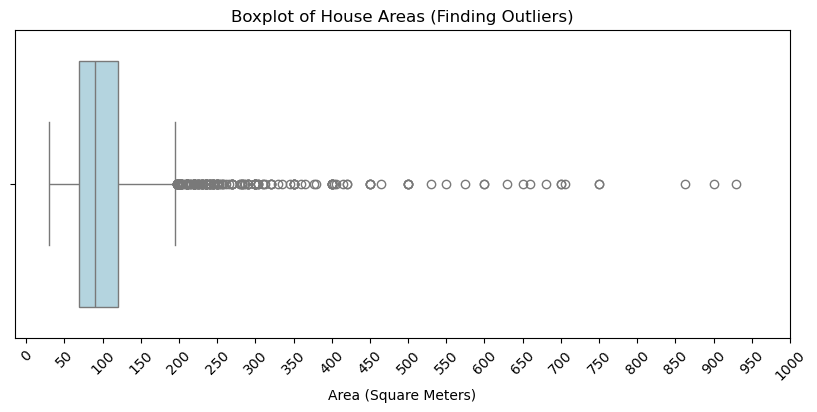

In [79]:
plt.figure(figsize=(10, 4))
#تبدیل مساحت به عدد
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
sns.boxplot(x=df['Area'], color='lightblue')
plt.title('Boxplot of House Areas (Finding Outliers)')
plt.xlabel('Area (Square Meters)')
plt.xticks(range(0, 1050, 50), rotation=45) 
plt.show()


کد مربوط بهپاک کردن داده های بالای 190 متر

In [80]:
df = df[df['Area'] <= 175]
df = df.reset_index(drop=True)

# چاپ دوباره نمودار

نمودار را دوباره چاپ میکنیم و متوجه میشویم که داده های ما به اندازه زیادی بهینه تر شده برای اینکه دقیق تر شود باید محدوده خودان را بالای 175 متر میگذاشتیم(طبق محاسبات ریاضی مربوط بهچارک ها)

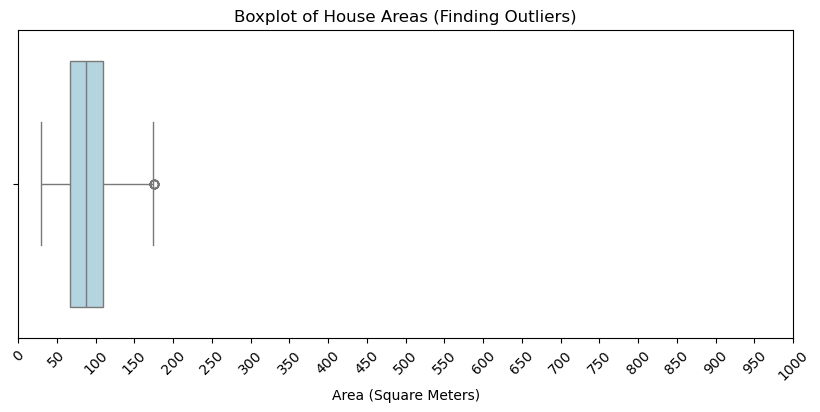

In [81]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Area'], color='lightblue')
plt.title('Boxplot of House Areas (Finding Outliers)')
plt.xlabel('Area (Square Meters)')
plt.xticks(range(0, 1050, 50), rotation=45) 
plt.show()

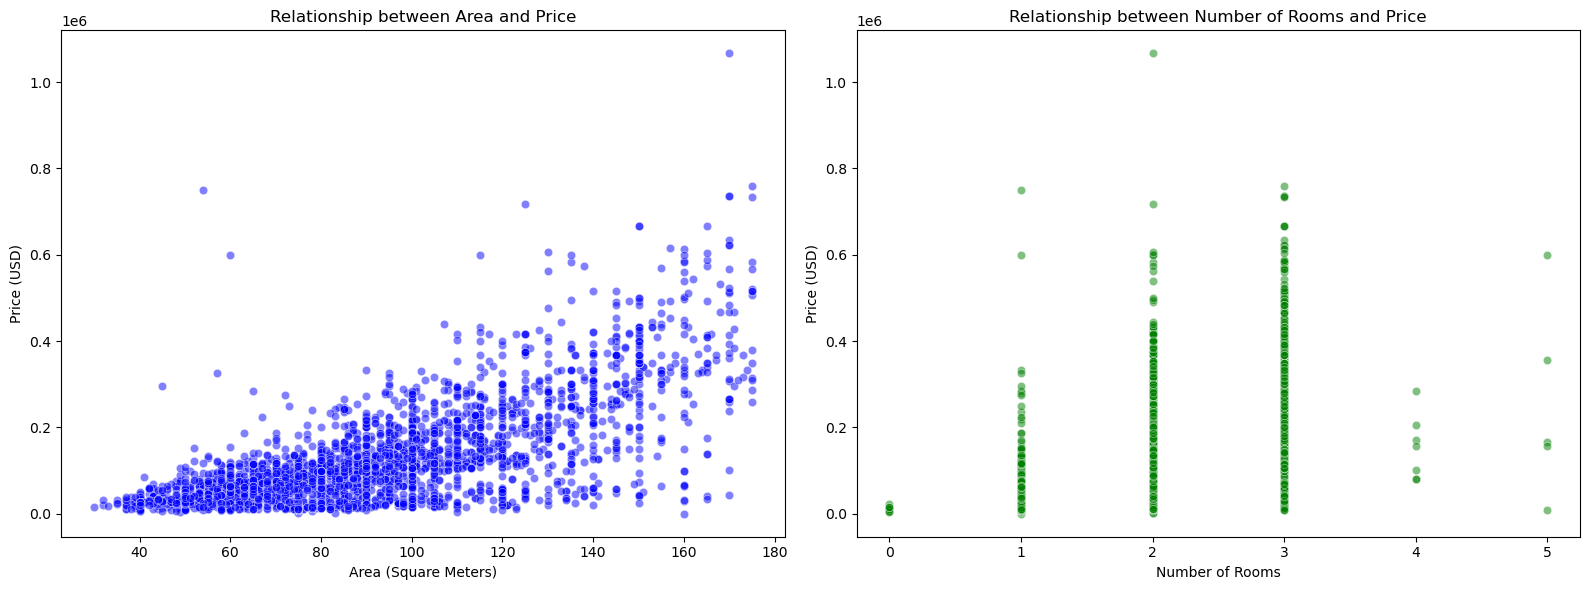

In [82]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='Area', y='Price(USD)', ax=axes[0], alpha=0.5, color='blue')
axes[0].set_title('Relationship between Area and Price')
axes[0].set_xlabel('Area (Square Meters)')
axes[0].set_ylabel('Price (USD)')
sns.scatterplot(data=df, x='Room', y='Price(USD)', ax=axes[1], alpha=0.5, color='green')
axes[1].set_title('Relationship between Number of Rooms and Price')
axes[1].set_xlabel('Number of Rooms')
axes[1].set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()


# روش تحلیل
داده های ما به صورتی هستند که محل خانه بیار تاثیر مهمی در قیمت ان میگذارد پس باید از روش رگرسیو
random forest 
استفاده کرد و به هر محله یک عدد 1 یا صفر تعلق میگیرد به روش
one hot encoding

In [83]:
df_encoded = pd.get_dummies(df, columns=['Address'], drop_first=True)
print(df_encoded.head())

    Area  Room  Parking  Warehouse  Elevator         Price  Price(USD)  \
0   63.0     1     True       True      True  1.850000e+09    61666.67   
1   60.0     1     True       True      True  1.850000e+09    61666.67   
2   79.0     2     True       True      True  5.500000e+08    18333.33   
3   95.0     2     True       True      True  9.025000e+08    30083.33   
4  123.0     2     True       True      True  7.000000e+09   233333.33   

   Address_Abbasabad  Address_Abuzar  Address_Afsarieh  ...  \
0              False           False             False  ...   
1              False           False             False  ...   
2              False           False             False  ...   
3              False           False             False  ...   
4              False           False             False  ...   

   Address_Waterfall  Address_West Ferdows Boulevard  Address_West Pars  \
0              False                           False              False   
1              False      

In [84]:
msk = np.random.rand(len(df_encoded)) < 0.8
train = df_encoded[msk]
test = df_encoded[~msk]
y_train = train['Price(USD)']
cols_to_drop = ['Price', 'Price(USD)', 'Room', 'Parking', 'Warehouse', 'Elevator']
existing_cols_to_drop = [col for col in cols_to_drop if col in train.columns]
X_train = train.drop(existing_cols_to_drop, axis=1)
y_test = test['Price(USD)']
X_test = test.drop(existing_cols_to_drop, axis=1)

کد های ترین کردن داده و پرینت عدد های مربوط به خطایابی

In [85]:

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2: {r2:.2f}")
print(f" (RMSE): {rmse:,.0f} $")


R2: 0.80
 (RMSE): 49,305 $
